In [80]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [81]:
def compute_metrics(X, D, R, name=""):
    X_hat = D @ R  # (d, N)

    errors = (
        np.linalg.norm(X - X_hat, axis=0) /
        np.linalg.norm(X, axis=0)
    ) * 100

    sparsity = np.sum(np.abs(R) > 1e-4, axis=0)
    sparsity_ratio = np.mean(np.abs(R) > 1e-4)

    print(f"\n===== {name} =====")
    print(f"Avg error: {errors.mean():.4f}")
    print(f"Std error: {errors.std():.4f}")
    print(f"Avg sparsity: {sparsity.mean():.2f}")
    print(f"Sparsity ratio: {sparsity_ratio:.4f}")

    return errors, sparsity


In [82]:
data_dir = "./data/"
X1 = np.load(data_dir + "mnist_emb_model1.npy")
X2 = np.load(data_dir + "mnist_emb_model2.npy")
X3 = np.load(data_dir + "mnist_emb_model3.npy")


#X_1 = StandardScaler().fit_transform(X1)
#X_1 = X_1  # -> (d, N)
#X_2 = StandardScaler().fit_transform(X2)
#X_2 = X_2  # -> (d, N)
#X_3 = StandardScaler().fit_transform(X3)
#X_3 = X_3  # -> (d, N)

norm = np.linalg.norm(X1, axis=1, keepdims=True)   # shape (1, n)
X_1 = X1 / norm
norm = np.linalg.norm(X2, axis=1, keepdims=True)   # shape (1, n)
X_2 = X2 / norm
norm = np.linalg.norm(X3, axis=1, keepdims=True)   # shape (1, n)
X_3 = X3 / norm


d, N = X_1.shape
K = int(X_1.shape[0] * 3.0)
k_sparsity = int(d * 0.1)

print(f"d: {d}, N: {N}, K: {K}, k_sparsity: {k_sparsity}")
print("Data shape:", X_1.shape, X_2.shape, X_3.shape)



X_dict = {
    0: torch.tensor(X_1.T).float(),  # (d x n)
    1: torch.tensor(X_2.T).float(),
    2: torch.tensor(X_3.T).float()
}
""" 
X_dict = create_correlated_datasets(
    X_base=X_1,   # your original dataset
    n_users=3,
    n_total=d,
    n_shared=50   # 40% shared
)
 """

d: 60000, N: 128, K: 180000, k_sparsity: 6000
Data shape: (60000, 128) (60000, 128) (60000, 128)


' \nX_dict = create_correlated_datasets(\n    X_base=X_1,   # your original dataset\n    n_users=3,\n    n_total=d,\n    n_shared=50   # 40% shared\n)\n '

In [83]:
from utils import SingleUserSCADict

num_users = 3


device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# DEFINE GRAPH
# =========================================================
edges = [
    (0, 1),
    (1, 2),
    (0, 2)
]

# =========================================================
# MODEL
# =========================================================
d, N = X_1.T.shape
print(d, N)
K = int(d * 2.0)
k_sparsity = int(d * 0.1)

model = SingleUserSCADict(
    d=d,
    K=K,
    k_sparsity=k_sparsity,
    rho=10.0,
    alpha=0.9,
    gamma=0.999,
    beta=0,
    device=device
)

# =========================================================
# TRAIN
# =========================================================
D, S, losses = model.fit(X_dict[0], outer_iters=200)

# =========================================================
# EVALUATION
# =========================================================
print("\n===== FINAL EVALUATION =====")

recon_error = 0.0
sparsity = 0.0

for _, (i, X_i) in zip(range(1), X_dict.items()):
    X_i = X_i.to(device)
    S_i = S
    print(model.D.shape, X_i.shape, S_i.shape)
    recon = model.D @ S_i
    recon_error += torch.norm(X_i - recon).item()

    sparsity += torch.mean((S_i.abs() > 1e-6).float()).item()

print(f"Reconstruction error: {recon_error:.4f}")
print(f"Sparsity: {sparsity / num_users:.4f}")


128 60000
iter 1: loss=210.773483
0.8991 0.999 0
iter 2: loss=138.389465
0.8982009 0.999 0
iter 3: loss=85.904823
0.8973026990999999 0.999 0
iter 4: loss=146.160751
0.8964053964008999 0.999 0
iter 5: loss=104.563324
0.895508991004499 0.999 0
iter 6: loss=220.095032
0.8946134820134944 0.999 0
iter 7: loss=166.514297
0.893718868531481 0.999 0
iter 8: loss=53.834419
0.8928251496629495 0.999 0
iter 9: loss=218.822525
0.8919323245132865 0.999 0
iter 10: loss=59.893600
0.8910403921887733 0.999 0
iter 11: loss=238.245132
0.8901493517965845 0.999 0
iter 12: loss=64.051712
0.889259202444788 0.999 0
iter 13: loss=90.823845
0.8883699432423432 0.999 0
iter 14: loss=32.725971
0.8874815732991008 0.999 0
iter 15: loss=50.783344
0.8865940917258017 0.999 0
iter 16: loss=25.728964
0.885707497634076 0.999 0
iter 17: loss=39.179798
0.8848217901364419 0.999 0
iter 18: loss=25.369926
0.8839369683463054 0.999 0
iter 19: loss=33.317131
0.8830530313779591 0.999 0
iter 20: loss=25.984362
0.8821699783465812 0.99

In [84]:
k_sparsity

12

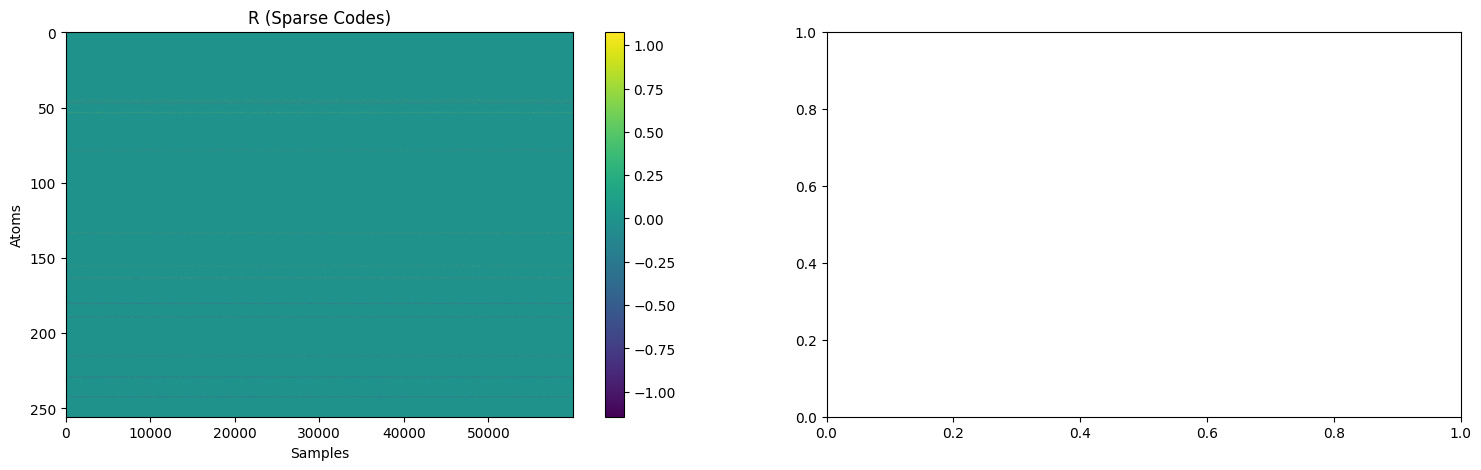

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S.cpu().numpy(), aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])

In [86]:
X_np = X_dict[0].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S.detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="SCA"
)


===== SCA =====
Avg error: 7.3091
Std error: 1.8582
Avg sparsity: 12.00
Sparsity ratio: 0.0469


In [88]:
np.mean(np.linalg.norm(D_np @ R_np - X_np, axis=0) / np.linalg.norm(X_np, axis=0)) * 100

np.float32(7.309071)

In [91]:
print(X_np.shape)
print(np.linalg.norm(X_np, axis=0))

(128, 60000)
[1.         1.         1.         ... 0.99999994 0.99999994 0.99999994]
